In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

data_path = '/content/drive/MyDrive/NOT_CRACKED_1/'

print(f"Number of images: {len(os.listdir(data_path))}")
print(f"First 5 files: {os.listdir(data_path)[:5]}")

Mounted at /content/drive
Number of images: 1888
First 5 files: ['IMG_20220817_153349.jpg', 'IMG_20220817_155103.jpg', 'IMG_20220816_143057.jpg', 'IMG_20220816_143731.jpg', 'IMG_20220817_152725.jpg']


In [ ]:
!pip install torch torchvision opencv-python albumentations

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from albumentations import CLAHE, Normalize
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, Subset
from torchvision import models

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score


In [7]:
import os
from pathlib import Path

source_good = Path("/content/drive/MyDrive/NOT_CRACKED_1")
source_bad  = Path("/content/drive/MyDrive/Test_Egg/Bad")

dest_root = Path("/content/egg_dataset")

In [8]:
(train_good := dest_root / "train" / "Good").mkdir(parents=True, exist_ok=True)
(test_good  := dest_root / "test" / "Good").mkdir(parents=True, exist_ok=True)
(test_bad   := dest_root / "test" / "Bad").mkdir(parents=True, exist_ok=True)

In [9]:
import random
import shutil

TEST_SPLIT = 0.2

def split_copy(src_folder, train_folder, test_folder):
    files = list(src_folder.glob("*.jpg")) + \
            list(src_folder.glob("*.png")) + \
            list(src_folder.glob("*.jpeg"))

    random.shuffle(files)
    test_size = int(len(files) * TEST_SPLIT)

    test_files  = files[:test_size]
    train_files = files[test_size:]

    for f in train_files:
        shutil.copy(f, train_folder / f.name)

    for f in test_files:
        shutil.copy(f, test_folder / f.name)

    print(f"{src_folder.name}: {len(train_files)} train | {len(test_files)} test")


split_copy(source_good, train_good, test_good)



NOT_CRACKED_1: 1511 train | 377 test


In [10]:
from pathlib import Path
import shutil

source_bad  = Path("/content/drive/MyDrive/Test_Egg/Bad")

dest_root = Path("/content/egg_dataset")



(test_bad   := dest_root / "test"  / "bad").mkdir(parents=True, exist_ok=True)


def copy_all(src, dst):
    files = []
    for ext in ["*.jpg","*.png","*.jpeg","*.JPG","*.PNG"]:
        files += list(src.glob(ext))

    for f in files:
        shutil.copy(f, dst / f.name)

    print(f"Copied {len(files)} → {dst}")


copy_all(source_bad, test_bad)


Copied 91 → /content/egg_dataset/test/bad

✔ Dataset ready for anomalib!



Testing mode: crop
Tensor shape: torch.Size([3, 256, 256]) Label: 1


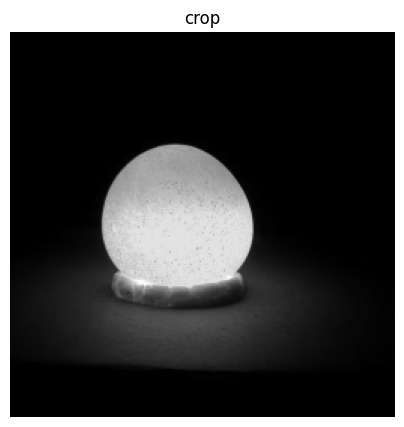


Testing mode: clahe
Tensor shape: torch.Size([3, 256, 256]) Label: 1


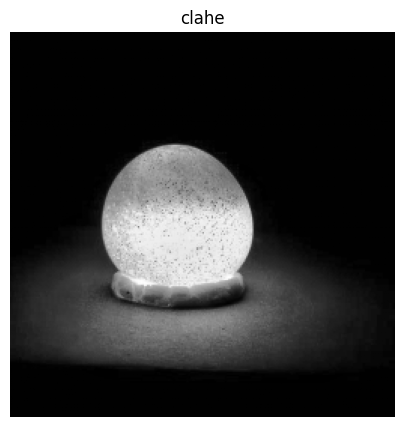


Testing mode: edges_only
Tensor shape: torch.Size([3, 256, 256]) Label: 1


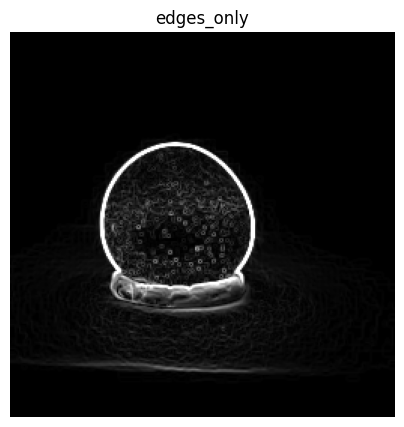


Testing mode: combined
Tensor shape: torch.Size([3, 256, 256]) Label: 1


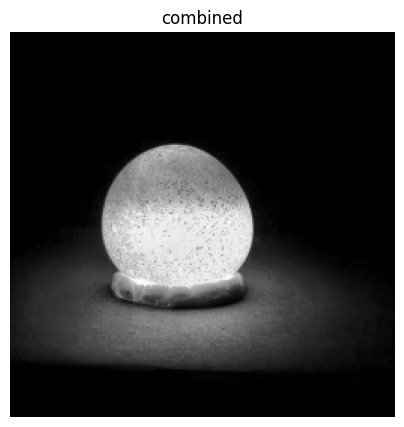


Testing mode: morph


UnboundLocalError: cannot access local variable 'out' where it is not associated with a value


Testing mode: crop
Tensor shape: torch.Size([3, 256, 256]) Label: 1


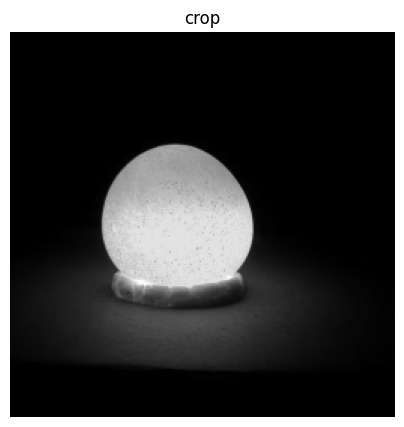


Testing mode: clahe
Tensor shape: torch.Size([3, 256, 256]) Label: 1


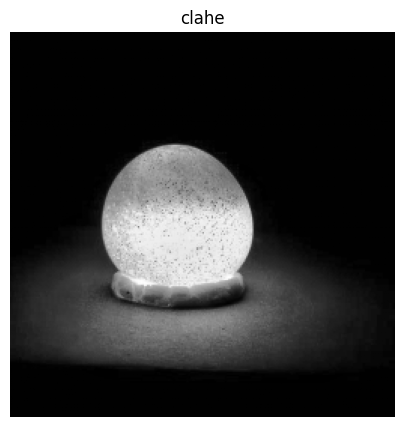


Testing mode: edges_only
Tensor shape: torch.Size([3, 256, 256]) Label: 1


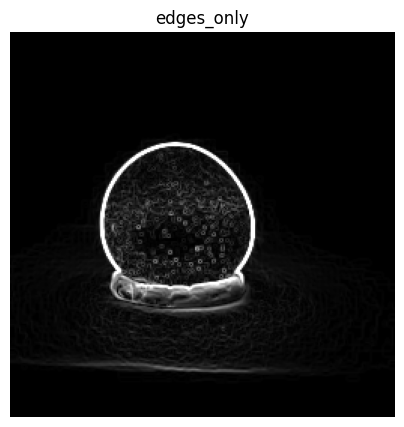


Testing mode: combined
Tensor shape: torch.Size([3, 256, 256]) Label: 1


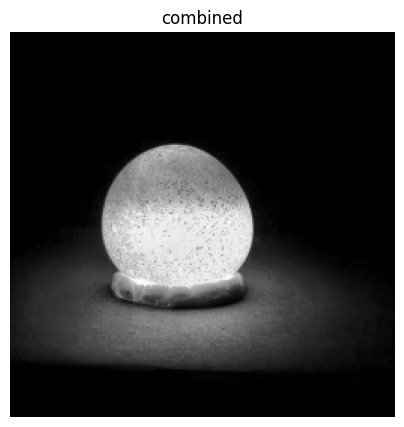


Testing mode: morph


UnboundLocalError: cannot access local variable 'out' where it is not associated with a value

In [ ]:
import matplotlib.pyplot as plt
from preprocess import EggDataset
def test_preprocess(dataset_path, modes):
    for mode in modes:
        print(f"\nTesting mode: {mode}")
        ds = EggDataset(dataset_path, mode=mode)
        x, y = ds[0]

        print("Tensor shape:", x.shape, "Label:", y)

        # Convert back to HWC for visualization
        img = x.permute(1,2,0).numpy()

        plt.figure(figsize=(5,5))
        plt.imshow(img[:,:,0], cmap="gray")
        plt.title(mode)
        plt.axis("off")
        plt.show()
test_preprocess(
    dataset_path="egg_dataset/train",
    modes=["crop", "clahe", "edges_only", "combined","morph"]
)

In [70]:
import cv2
import numpy as np
import torch
from pathlib import Path
class EggDataset(torch.utils.data.Dataset):
    def __init__(self, folder, mode="baseline"):
        self.paths = list(Path(folder).glob("*/*.jpg"))
        self.mode = mode

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):

        path = self.paths[i]
        label = 0 if "Good" in str(path) else 1
        crop_size=200
        img = cv2.imread(str(path))

        gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray_image, (5,5), 0)
        img = cv2.resize(blur, (256, 256))

        if self.mode == "crop":
          img=img[56:-56,56:-56]
          img = cv2.resize(img, (256, 256))
          out = np.stack([img, img, img], axis=2)

        elif self.mode == "clahe":
          #gray
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            cl1 = clahe.apply(img)
            out = np.stack([cl1, cl1, cl1], axis=2)


        elif self.mode == "combined":
            #img=img[56:-56,56:-56]
            #img = cv2.resize(img, (256, 256))
            sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
            sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges
            gradient_magnitude = cv2.magnitude(sobelx, sobely)
            gradient_magnitude = cv2.convertScaleAbs(gradient_magnitude)
            sobell=gradient_magnitude

            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            cl1 = clahe.apply(img)
            clahee=cl1

            laplacian = cv2.Laplacian(img, cv2.CV_64F)
            lap = cv2.convertScaleAbs(laplacian)

            out = np.stack([clahee, sobell, lap], axis=2)


        elif self.mode == "edges_only":
            sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
            sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges
            gradient_magnitude = cv2.magnitude(sobelx, sobely)
            gradient_magnitude = cv2.convertScaleAbs(gradient_magnitude)
            out = np.stack([gradient_magnitude, gradient_magnitude, gradient_magnitude], axis=2)


        if self.mode == "morph":

            sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # Horizontal edges
            sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # Vertical edges
            gradient_magnitude = cv2.magnitude(sobelx, sobely)
            sobel= cv2.convertScaleAbs(gradient_magnitude)

            _, mask = cv2.threshold(sobel, 30, 255, cv2.THRESH_BINARY)
            shape=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
            opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, shape)

            out = np.stack([opening,opening,opening], axis=2)


        out = out.astype("float32") / 255.0
        out = torch.tensor(out).permute(2,0,1)
        return out,label





Testing mode: crop
Tensor shape: torch.Size([3, 256, 256]) Label: 1


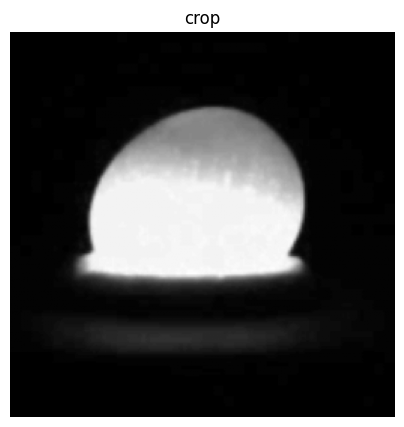


Testing mode: clahe
Tensor shape: torch.Size([3, 256, 256]) Label: 1


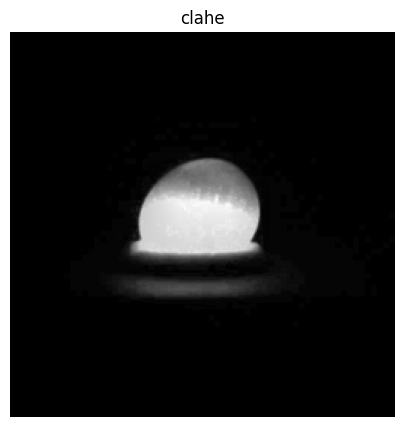


Testing mode: edges_only
Tensor shape: torch.Size([3, 256, 256]) Label: 1


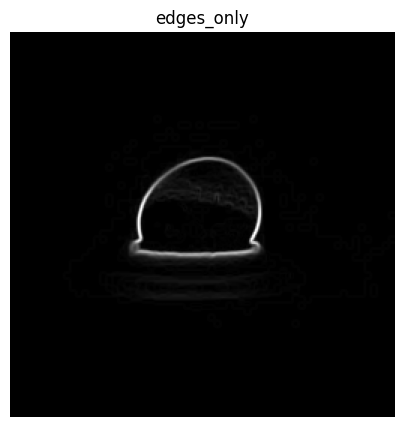


Testing mode: combined
Tensor shape: torch.Size([3, 256, 256]) Label: 1


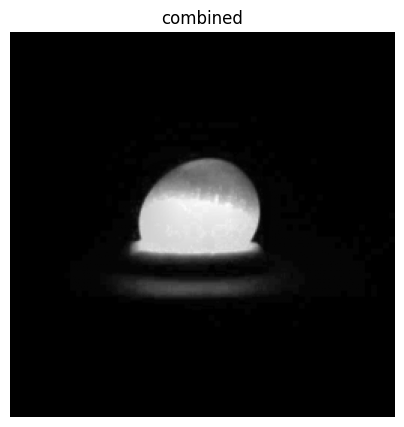


Testing mode: morph
Tensor shape: torch.Size([3, 256, 256]) Label: 1


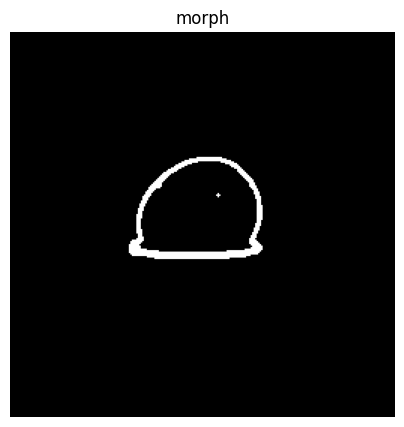

In [69]:
import matplotlib.pyplot as plt
def test_preprocess(dataset_path, modes):
    for mode in modes:
        print(f"\nTesting mode: {mode}")
        ds = EggDataset(dataset_path, mode=mode)
        x, y = ds[0]

        print("Tensor shape:", x.shape, "Label:", y)

        img = x.permute(1,2,0).numpy()

        plt.figure(figsize=(5,5))
        plt.imshow(img[:,:,0], cmap="gray")
        plt.title(mode)
        plt.axis("off")
        plt.show()
test_preprocess(
    dataset_path="kachoow/kachoow2",
    modes=["crop", "clahe", "edges_only", "combined","morph"]
)

In [72]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
 #thank you dr.ji and csce 421 for giving me the outline for this
def feature_extract():
    model = models.resnet50(pretrained=True)
    model = nn.Sequential(*list(model.children())[:-1])
    model.eval()
    for param in model.parameters():
        param.requires_grad = False
    return model

def extract_features(model, loader, device):
    features = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feat = model(x).squeeze(-1).squeeze(-1)
            features.append(feat.cpu())
            labels.extend(y.tolist())
    features = torch.cat(features, dim=0).numpy()
    labels = np.array(labels)
    return features, labels


def good_loader(path, mode, batch_size=16):
    ds = EggDataset(path, mode=mode)
    good_idx = [i for i in range(len(ds)) if ds[i][1] == 0]
    ds_good = Subset(ds, good_idx)
    return DataLoader(ds_good, batch_size=batch_size, shuffle=False)


def all_loader(path, mode, batch_size=16):
    ds = EggDataset(path, mode=mode)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


def run_anomaly_detection(mode,method,contamination):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_good = good_loader("egg_dataset/train", mode=mode, batch_size=16)
    test_all = all_loader("egg_dataset/test", mode=mode, batch_size=8)

    #extract
    feature_extractor = feature_extract().to(device)

    train_features, _ = extract_features(feature_extractor, train_good, device)
    test_features, test_labels = extract_features(feature_extractor, test_all, device)

    print(f"Train features: {train_features.shape} (all good eggs)")
    print(f"Test features: {test_features.shape}")
    print(f"Test distribution: Good={np.sum(test_labels==0)}, Cracked={np.sum(test_labels==1)}")

    print(f"\nTraining {method} on normal eggs...")

    clf = IsolationForest(
    contamination=contamination,
    random_state=42,
    n_estimators=200,
    max_samples='auto')

    clf.fit(train_features)

    predictions = clf.predict(test_features)
    predictions = np.where(predictions == 1, 0, 1)

    scores = -clf.score_samples(test_features)

    scores = (scores - scores.min()) / (scores.max() - scores.min() )

    accuracy = np.mean(predictions == test_labels)
    auc = roc_auc_score(test_labels, scores)
    print(f"\nAUC-ROC: {auc:.4f}")

    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(test_labels, predictions,
                                target_names=['Good', 'Cracked'],
                                zero_division=0))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(test_labels, predictions)
    print(cm)
    print("([[True Good, False Cracked],")
    print("  [False Good, True Cracked]])")

    # Calculate per-class metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)

    print(f"\nCrack Detection Metrics:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Single experiment
result = run_anomaly_detection(mode="morph", method="iforest", contamination=0.1)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train features: (1129, 2048) (all good eggs)
Test features: (364, 2048)
Test distribution: Good=273, Cracked=91

Training iforest on normal eggs...

AUC-ROC: 0.8477
Accuracy: 0.8187

Classification Report:
              precision    recall  f1-score   support

        Good       0.85      0.92      0.88       273
     Cracked       0.69      0.51      0.58        91

    accuracy                           0.82       364
   macro avg       0.77      0.71      0.73       364
weighted avg       0.81      0.82      0.81       364


Confusion Matrix:
[[252  21]
 [ 45  46]]
([[True Good, False Cracked],
  [False Good, True Cracked]])

Crack Detection Metrics:
  Precision: 0.6866
  Recall: 0.5055
  F1-Score: 0.5823
